Saving Tennis.csv to Tennis (1).csv
Dataset Preview:
    outlook temperature humidity  windy play_tennis
0     sunny         hot     high  False          no
1     sunny         hot     high   True          no
2  overcast         hot     high  False         yes
3     rainy        mild     high  False         yes
4     rainy        cold   normal  False         yes

After Encoding:
   outlook  temperature  humidity  windy  play_tennis
0        2            1         0      0            0
1        2            1         0      1            0
2        0            1         0      0            1
3        1            2         0      0            1
4        1            0         1      0            1

Accuracy: 0.6666666666666666


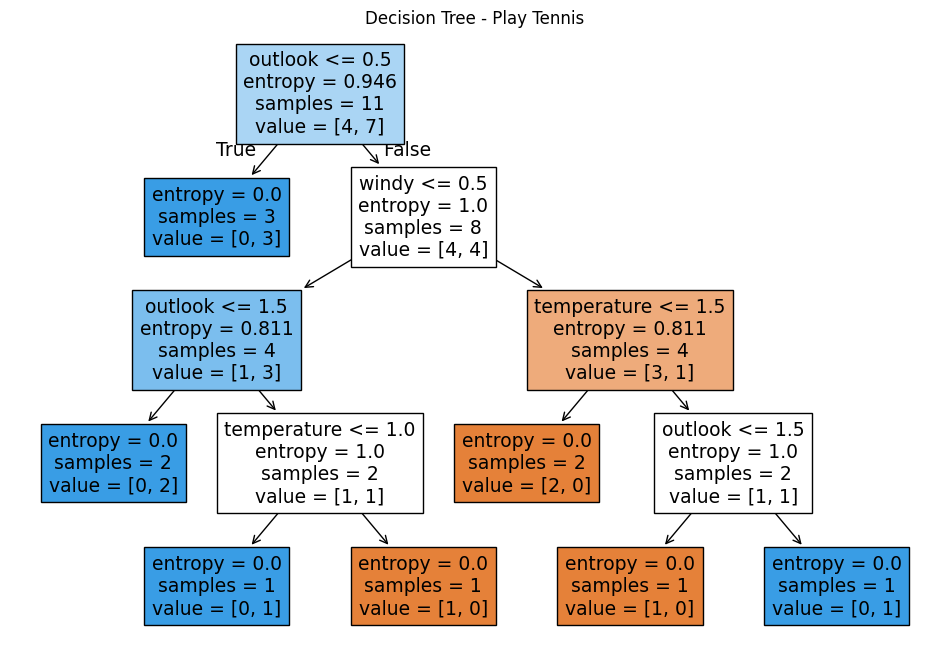

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

df = pd.read_csv('Tennis.csv')

df.columns = df.columns.str.strip().str.lower()

df.rename(columns={
    'temprature': 'temperature',
    'play tennis': 'play_tennis'
}, inplace=True)

print("Dataset Preview:")
print(df.head())

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

print("\nAfter Encoding:")
print(df.head())

X = df.drop('play_tennis', axis=1)
y = df['play_tennis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

plt.figure(figsize=(12,8))
plot_tree(model, filled=True, feature_names=X.columns)
plt.title("Decision Tree - Play Tennis")
plt.show()